# 04 — Shapes walkthrough

**Phase 3.** One forward pass narrated tensor-by-tensor, the param budget across tiers, an
attention-weight heatmap of the untrained L-tier model, and the classic overfit-one-batch
sanity check. Model code: `src/llmlab/model/`. Sizing/aspect-ratio decisions: D-015; baseline
hyperparameter defaults (tying, head_dim, dropout, init): D-016.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tokenizers import Tokenizer

sys.path.insert(0, "../src")
from llmlab.model import GPT, ModelConfig
from llmlab.utils import autocast_ctx, get_device, mem_stats, set_seed

set_seed(42)
device = get_device()
print(f"device: {device}")


device: mps


## 1. Config -> model

We narrate the forward pass on **S-tier** (small enough to print every shape without
scrolling forever), then look at the param budget across all three tiers.

In [2]:
cfg = ModelConfig.from_yaml("../configs/model_s.yaml")
model = GPT(cfg).to(device)
print(cfg)
print(f"\ntotal params: {model.num_params():,} ({model.num_params()/1e6:.2f}M)")


ModelConfig(vocab_size=16000, d_model=192, n_layers=15, n_heads=3, n_kv_heads=3, head_dim=64, max_seq_len=512, dropout=0.0, norm='rmsnorm', norm_position='pre', qk_norm=False, pos_encoding='rope', rope_theta=10000.0, ffn='swiglu', ffn_mult=2.6667, attention='mha_gqa', mla=None, tie_embeddings=True, init='gpt2', moe=None, mtp=None)

total params: 9,713,472 (9.71M)


## 2. Where do the params live?

Per `docs/learnings/20260711_parameter-allocation.md`: embedding params are a lookup table (no
compute per token), block (attention+FFN) params are the "active"/compute-doing params that
predict capability (Kaplan/Chinchilla count these, not the total). Smaller models are
embedding-heavier — watch the embed% shrink as we go S -> M -> L below.

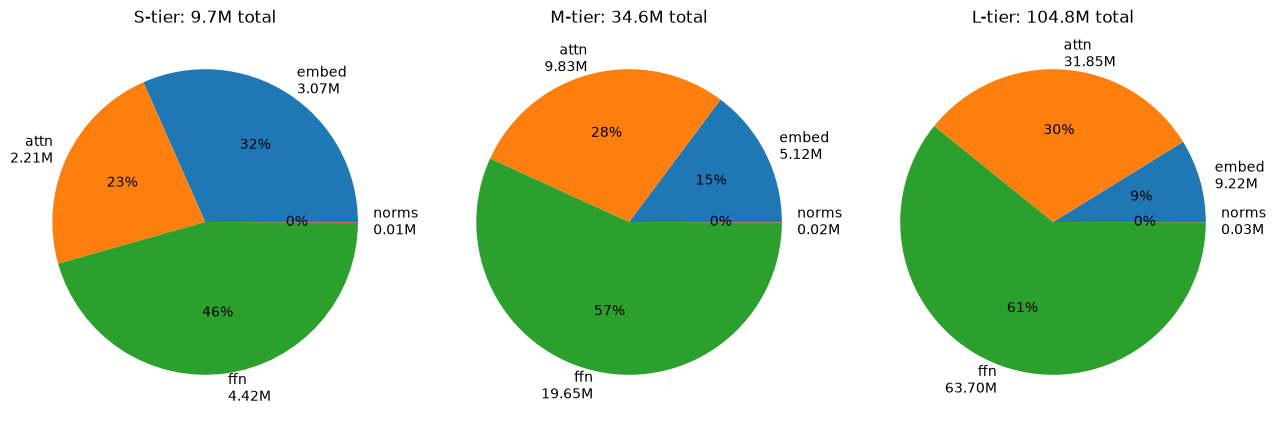

tier  d_model  layers  heads      embed     active      total
S         192      15      3      3.07M      6.64M      9.71M
M         320      24      5      5.12M     29.50M     34.62M
L         576      24      9      9.22M     95.58M    104.80M


In [3]:
tiers = ["s", "m", "l"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
rows = []
for ax, tier in zip(axes, tiers):
    tcfg = ModelConfig.from_yaml(f"../configs/model_{tier}.yaml")
    tmodel = GPT(tcfg)
    b = tmodel.num_params(breakdown=True)
    slices = {k: v for k, v in b.items() if k not in ("total", "pos_embed") and v > 0}
    ax.pie(slices.values(), labels=[f"{k}\n{v/1e6:.2f}M" for k, v in slices.items()], autopct="%1.0f%%")
    ax.set_title(f"{tier.upper()}-tier: {b['total']/1e6:.1f}M total")
    rows.append((tier.upper(), tcfg.d_model, tcfg.n_layers, tcfg.n_heads, b["embed"], b["total"] - b["embed"], b["total"]))
plt.tight_layout()
plt.show()

print(f"{'tier':4s} {'d_model':>8s} {'layers':>7s} {'heads':>6s} {'embed':>10s} {'active':>10s} {'total':>10s}")
for r in rows:
    print(f"{r[0]:4s} {r[1]:8d} {r[2]:7d} {r[3]:6d} {r[4]/1e6:9.2f}M {r[5]/1e6:9.2f}M {r[6]/1e6:9.2f}M")


## 3. Tensor-by-tensor forward pass (S-tier)

We call the model's own submodules directly (not `model.forward`) so every intermediate shape
is visible. Using a real tokenized snippet from the corpus rather than random ints, so the
attention heatmap in section 5 shows something legible.

In [4]:
tok = Tokenizer.from_file("../data/tokenized/tokenizers/hf_bpe_16k/tokenizer.json")
text = "The unexamined life is not worth living, said the philosopher to his students."
ids = tok.encode(text).ids
tokens_str = [tok.decode([i]) for i in ids]
print(f"text: {text!r}")
print(f"{len(ids)} tokens: {ids}")
print(f"pieces: {tokens_str}")

x = torch.tensor([ids], device=device)  # (B=1, T)
B, T = x.shape
print(f"\ninput idx shape: {tuple(x.shape)}  (B={B}, T={T})")


text: 'The unexamined life is not worth living, said the philosopher to his students.'
17 tokens: [674, 479, 4632, 1004, 735, 311, 351, 1726, 2073, 15, 716, 266, 1823, 283, 377, 13484, 17]
pieces: ['The', ' un', 'exam', 'ined', ' life', ' is', ' not', ' worth', ' living', ',', ' said', ' the', ' philosopher', ' to', ' his', ' students', '.']

input idx shape: (1, 17)  (B=1, T=17)


In [5]:
with torch.no_grad():
    h = model.tok_emb(x)
    print(f"after tok_emb:          {tuple(h.shape)}   (B, T, d_model={cfg.d_model})")
    if model.pos_emb is not None:
        h = h + model.pos_emb(T, x.device)
        print(f"after + pos_emb:        {tuple(h.shape)}   ({cfg.pos_encoding} adds an absolute position vector here)")
    else:
        print(f"pos_encoding={cfg.pos_encoding!r}: no additive positional term — injected inside attention instead")
    h = model.drop(h)

    block0 = model.blocks[0]
    normed = block0.attn_norm(h)
    print(f"after attn_norm (block0): {tuple(normed.shape)}   (shape unchanged — norm is per-vector)")

    attn = block0.attn
    q = attn.q_proj(normed).view(B, T, attn.n_heads, attn.head_dim).transpose(1, 2)
    k = attn.k_proj(normed).view(B, T, attn.n_kv_heads, attn.head_dim).transpose(1, 2)
    v = attn.v_proj(normed).view(B, T, attn.n_kv_heads, attn.head_dim).transpose(1, 2)
    print(f"q_proj -> heads:        {tuple(q.shape)}   (B, n_heads={attn.n_heads}, T, head_dim={attn.head_dim})")
    print(f"k_proj -> heads:        {tuple(k.shape)}   (B, n_kv_heads={attn.n_kv_heads}, T, head_dim={attn.head_dim}) — n_kv_heads==n_heads here (plain MHA)")
    print(f"v_proj -> heads:        {tuple(v.shape)}")

    if attn.rotary is not None:
        cos, sin = attn.rotary(T, x.device)
        print(f"RoPE cos/sin tables:    {tuple(cos.shape)}   (T, head_dim) — same shape added to every head")

    attn_out = block0(h)  # full block forward (attn sublayer + ffn sublayer + both residuals)
    print(f"\nblock0 output:          {tuple(attn_out.shape)}   (unchanged through all {cfg.n_layers} blocks)")


after tok_emb:          (1, 17, 192)   (B, T, d_model=192)
pos_encoding='rope': no additive positional term — injected inside attention instead
after attn_norm (block0): (1, 17, 192)   (shape unchanged — norm is per-vector)
q_proj -> heads:        (1, 3, 17, 64)   (B, n_heads=3, T, head_dim=64)
k_proj -> heads:        (1, 3, 17, 64)   (B, n_kv_heads=3, T, head_dim=64) — n_kv_heads==n_heads here (plain MHA)
v_proj -> heads:        (1, 3, 17, 64)
RoPE cos/sin tables:    (17, 64)   (T, head_dim) — same shape added to every head

block0 output:          (1, 17, 192)   (unchanged through all 15 blocks)


In [6]:
with torch.no_grad():
    h2 = h
    for i, block in enumerate(model.blocks):
        h2 = block(h2)
    print(f"after all {cfg.n_layers} blocks:      {tuple(h2.shape)}")

    h2 = model.final_norm(h2)
    print(f"after final_norm:       {tuple(h2.shape)}")

    logits = model.lm_head(h2)
    print(f"after lm_head:          {tuple(logits.shape)}   (B, T, vocab_size={cfg.vocab_size})")

    next_token_logits = logits[0, -1]
    top5 = torch.topk(next_token_logits, 5)
    print(f"\ntop-5 next-token guesses (untrained, so ~random):")
    for val, idx in zip(top5.values, top5.indices):
        print(f"  {tok.decode([idx.item()])!r:15s} logit={val.item():.3f}")


after all 15 blocks:      (1, 17, 192)
after final_norm:       (1, 17, 192)
after lm_head:          (1, 17, 16000)   (B, T, vocab_size=16000)

top-5 next-token guesses (untrained, so ~random):
  '.'             logit=1.407
  ' Mus'          logit=1.207
  'divisions'     logit=0.930
  'why'           logit=0.925
  ' thick'        logit=0.904


## 4. Causal mask — verified, not assumed

The whole point of a decoder-only LM is that position `t`'s logits may depend on positions
`<= t` and NEVER on positions `> t`. `tests/test_model.py::test_causal_mask_future_does_not_leak_into_past`
checks this for every `pos_encoding` variant; here's the same check inline, plus what the mask
actually looks like.

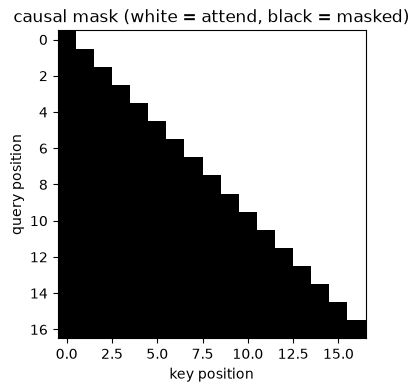

changing only the LAST token leaves all earlier logits unchanged: True


In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
mask = np.tril(np.ones((T, T)))
ax.imshow(mask, cmap="Greys")
ax.set_title("causal mask (white = attend, black = masked)")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
plt.show()

model.eval()
x_mod = x.clone()
x_mod[0, -1] = (x_mod[0, -1] + 1) % cfg.vocab_size
with torch.no_grad():
    logits_a, _ = model(x)
    logits_b, _ = model(x_mod)
past_unchanged = torch.allclose(logits_a[:, :-1], logits_b[:, :-1], atol=1e-5)
print(f"changing only the LAST token leaves all earlier logits unchanged: {past_unchanged}")


## 5. Attention-weight heatmap (untrained model)

`F.scaled_dot_product_attention` (used inside `Attention.forward`) doesn't hand back the
attention weights — it's a fused kernel. So for visualization only, we recompute the same
math (`softmax(QK^T / sqrt(head_dim) + causal_mask)`) by hand on the already-RoPE'd Q/K from
above. Expect a roughly-random-but-causal pattern: the model hasn't trained yet, so there's no
learned structure, but the lower-triangular constraint is already visible.

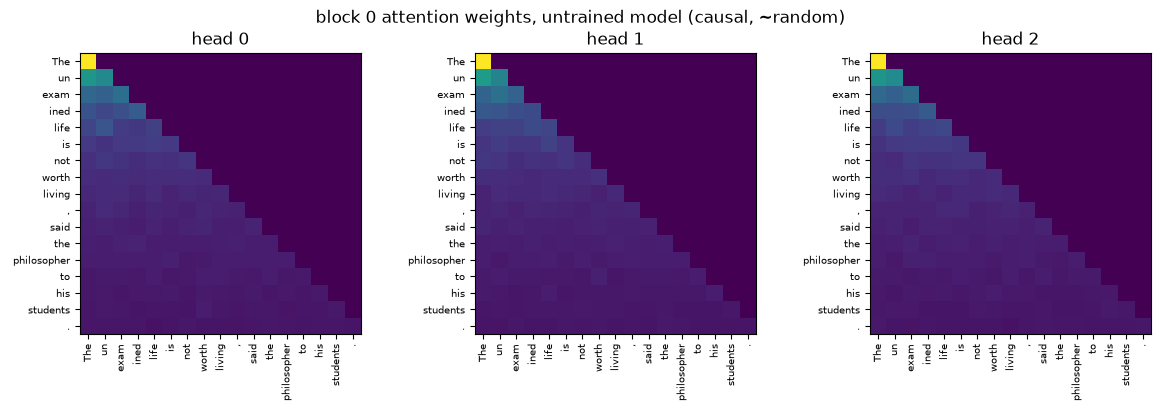

In [8]:
import torch.nn.functional as F

with torch.no_grad():
    qh, kh = q, k  # from section 3, already through RoPE
    scores = (qh @ kh.transpose(-2, -1)) / (attn.head_dim ** 0.5)
    causal = torch.triu(torch.full((T, T), float("-inf"), device=qh.device), diagonal=1)
    weights = F.softmax(scores + causal, dim=-1)  # (B, n_heads, T, T)

fig, axes = plt.subplots(1, attn.n_heads, figsize=(4 * attn.n_heads, 4))
if attn.n_heads == 1:
    axes = [axes]
for h_idx, ax in enumerate(axes):
    ax.imshow(weights[0, h_idx].cpu().numpy(), cmap="viridis")
    ax.set_title(f"head {h_idx}")
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens_str, rotation=90, fontsize=7)
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens_str, fontsize=7)
fig.suptitle("block 0 attention weights, untrained model (causal, ~random)")
plt.tight_layout()
plt.show()


## 6. Overfit one batch

The classic "can this model even learn" test: take ONE real batch, train on it repeatedly, and
confirm loss collapses toward zero. If it doesn't, something in the forward/backward path is
broken — no point starting a real training run until this passes.

In [9]:
import numpy as np

train_data = np.memmap("../data/tokenized/hf_bpe_16k/train.bin", dtype=np.uint16, mode="r")
seq_len = 64
batch_size = 8
start = 10_000  # arbitrary fixed offset -> a fixed, reproducible batch
batch_ids = np.stack([train_data[start + i * seq_len : start + i * seq_len + seq_len + 1] for i in range(batch_size)])
xb = torch.from_numpy(batch_ids[:, :-1].astype(np.int64)).to(device)
yb = torch.from_numpy(batch_ids[:, 1:].astype(np.int64)).to(device)
print(f"xb: {tuple(xb.shape)}, yb: {tuple(yb.shape)}")


xb: (8, 64), yb: (8, 64)


step    0  loss 9.7186


step   20  loss 4.6032


step   40  loss 4.5082


step   60  loss 4.0941


step   80  loss 3.4831


...

step  120  loss 1.5552


step  140  loss 0.9124


step  160  loss 0.4516


step  180  loss 0.1220


step  199  loss 0.0376


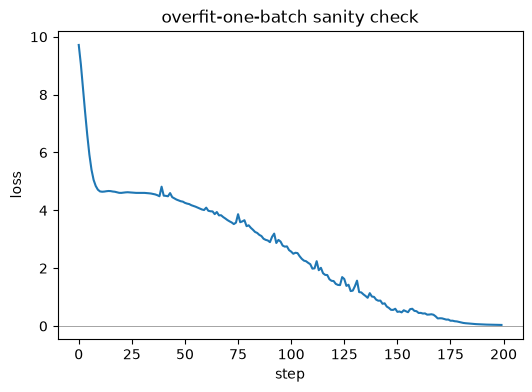


final loss: 0.0376 (started at 9.7186, ln(vocab)=9.68)
PASS: model can learn.


In [10]:
overfit_cfg = ModelConfig.from_yaml("../configs/model_s.yaml")
overfit_model = GPT(overfit_cfg).to(device)
opt = torch.optim.AdamW(overfit_model.parameters(), lr=3e-3)

losses = []
n_steps = 200
for step in range(n_steps):
    opt.zero_grad()
    with autocast_ctx(device):
        _, loss = overfit_model(xb, yb)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 20 == 0 or step == n_steps - 1:
        print(f"step {step:4d}  loss {loss.item():.4f}")

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.axhline(0, color="grey", lw=0.5)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("overfit-one-batch sanity check")
plt.show()

print(f"\nfinal loss: {losses[-1]:.4f} (started at {losses[0]:.4f}, ln(vocab)={np.log(overfit_cfg.vocab_size):.2f})")
assert losses[-1] < 0.5, "model failed to overfit a single batch — something is broken upstream"
print("PASS: model can learn.")


## Recap — learning checkpoints (phase 3 spec)

**Block diagram** (pre-norm, the baseline path):

```
tokens (B,T)
  -> tok_emb                              (B,T,d_model)
  -> [+ pos_emb]  (only if learned/sinusoidal; rope/alibi act inside attention instead)
  -> dropout
  -> for each of n_layers blocks:
       x = x + Attention(attn_norm(x))    # pre-norm: norm sees the block's INPUT
       x = x + FFN(ffn_norm(x))           # residual stream itself is never normalized
  -> final_norm
  -> lm_head                              (B,T,vocab_size)
```

**S-tier weight shapes** (`configs/model_s.yaml`: d_model=192, n_layers=15, n_heads=3, head_dim=64, vocab=16000):

| Module | Shape | Count |
|---|---|---|
| `tok_emb.weight` (tied w/ `lm_head.weight`) | (16000, 192) | 3.07M |
| per-layer `q_proj`/`o_proj` | (192, 192) each | 2 x 36.9K |
| per-layer `k_proj`/`v_proj` | (192, 192) each (MHA: n_kv_heads=n_heads) | 2 x 36.9K |
| per-layer FFN (`gate_proj`/`up_proj`/`down_proj`, swiglu) | (192, 512) x2 + (512, 192) | 3 x 98.3K |
| per-layer norms | (192,) x2 | negligible |
| `final_norm.weight` | (192,) | negligible |

**Why loss ~ ln(vocab_size) at init:** with weights ~N(0, 0.02) and no fan-in scaling, logits
start near-zero-variance across the vocab dimension, so softmax is ~uniform — cross-entropy of
a uniform distribution over V classes is exactly `ln(V)`. Verified in section 3's top-5 guesses
(essentially random) and in `test_loss_near_ln_vocab_at_init`.

**Why scale residual init by 1/sqrt(2*n_layers):** each block adds two contributions to the
residual stream (attention output, FFN output). With `n_layers` blocks that's `2*n_layers`
additions of roughly independent noise; without down-scaling, the residual stream's variance
grows ~linearly with depth, destabilizing very deep models at init. Scaling each
residual-writing projection by `1/sqrt(2*n_layers)` keeps the sum's variance ~constant
regardless of depth (D-016).

**Where params live:** embedding (lookup, no compute) vs attention+FFN ("active", all the
compute) — see section 2's pie charts. Embed share shrinks from ~32% (S) to ~9% (L) as
d_model grows faster than vocab stays fixed — full reasoning in
`docs/learnings/20260711_parameter-allocation.md`.